# MVP — Machine Learning & Analytics

**Nome:** _Rômulo A. T. Kohler_  
**Matrícula:** _4052026000334_  
**Data:** _29/06/2026_  
**Dataset:** _O dataset foi criado por mim, realizado a extração dos dados de 93 empresas com ações na B3 (CVM/DFP) e indicadores macroeonomicos (BCB/SGS) com um total de 1320 observações, esse dataset está disponível no link abaixo.
https://github.com/romulo-ratk/DATA-SCIENCE-ANALYTICS  
**Tipo de problema:** _Classificação binária supervisionada_  

---



## Checklist do MVP


| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |




# 1. Definição do problema

## 1.1 Descrição do problema


**Contexto**

Nos dias atuais ainda há um número muito pequeno da população brasileira que investe no mercado de ações. Muitos não investem por insegurança ou falta de informações verdadeiras e relevantes. Frente a isso, propus um modelo que irá interagir com dados de empresas com empresas brasileiras com o período histórico de 2010 até 2014 (dados retirados da CVM), empresas com líquidez e com dados suficientes para realizar testes e treinamentos de Machine Learning.

Este modelo recebe os dados individuais de cada empresa, do fechamento de cada ano contábil (rentabilidade, endividamento, valuation, entre outros) juntamente com o contexto macroecoônico (selic, pib, câmbio), todos dados anualizados e inseridos dentro de um dataset. Ao fim o modelo fará uma classificação da probabilidade de cada empresa superar ou não o índice Ibovespa em cada ano subsequente.

Como público alvo podemos ter investidores pessoas físicas, gestores de fundos ou de empresas, entre outros que visem operar e ter uma rentabilidade acima do índice do Ibovespa.



## 1.2 Objetivo do MVP

O Objetivo desse MVP é construir um modelo de Machine Learning para prever a probabilidade de uma ou mais ações do mercado brasileiro superarem ou não o índice do Ibovespa nos 12 meses seguintes, utilizando indicadores fundamentalistas anuais (retirados da CVM) e variáveis macroeconômicas (retirados do BCB), comparando uma abordagem baseline com modelos candidatos (Logistic Regresion, Randon Forrest, XGboost), assim como avaliando também as limitações de aplicação ao mercado brasileira.



## 1.3 Tipo de problema

Indique o tipo de problema e justifique.

- **Classificação:** prever uma classe/categoria.
- **Regressão:** prever um valor numérico contínuo.
- **Clusterização:** agrupar exemplos similares sem rótulo conhecido.
- **Séries temporais / forecasting:** prever valores futuros respeitando a ordem temporal.

**Tipo escolhido:** _Classificação e Séries Temporais_  
**Justificativa:** a avalição é discreta, (1 se a ação deve superar o índice Ibovespa no ano seguinte, 0 se não deve superar), não previsto o retorno, somente a probabilidade de superar ou não. O que torna a avalição mais simples e, em tese, mais fácil de prever_

Série temporal também é utilizada, pois vamos ter dados cronológicos (2010 até 2023), utilizando a divisão de treino/teste através de expanding window com 6 janelas e mais validação cruzada.



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. **Empresas com fundamentos melhores tendem a ir melhor na bolsa.** Empresas mais rentáveis, com menos dívida e crescendo mais devem superar o índice com mais frequência do que empresas com fundamentos ruins. Se essa relação não existir nos dados, qualquer modelo construído sobre fundamentos não vai funcionar.

2. **O contexto da economia influencia a relação entre fundamentos e retorno.** A mesma empresa endividada se comporta de forma diferente em ano de juro alto (penalizada) e juro baixo (favorecida). Combinar indicadores da empresa com variáveis macroeconômicas deve trazer mais informação do que olhar para cada bloco isoladamente.

3. **A relação entre fundamentos e retorno não é linear.** Decisões de análise fundamentalista envolvem combinações complexas — empresa com ROE alto mas dívida alta é arriscada; ROE alto com dívida baixa é excelente. Modelos que conseguem capturar essas interações devem ter desempenho superior a modelos que assumem relações lineares simples.

O modelo será considerado bem-sucedido se atender três critérios complementares, cada um respondendo a uma pergunta diferente:

**1. O modelo aprendeu alguma coisa real?**

Comparamos o desempenho do modelo com um chute aleatório. Se o modelo não consegue diferenciar uma ação que vai superar o índice de uma que não vai, então não há nada de útil ali — é apenas ruído. Para isso, foi usado uma métrica de classificação que mede a capacidade de ordenar corretamente as previsões.

**2. O modelo funcionaria na prática?**

 Foi imulado o seguinte cenário: a cada ano, um investidor olha o ranking de probabilidades gerado pelo modelo e monta uma carteira com as ações mais bem classificadas. No fim do ano, essa carteira teria superado o Ibovespa? Se isso acontecer na maioria dos anos testados, o modelo gera valor real para quem investe.

**3. O modelo funciona em condições reais, fora dos dados de treino?**

Como estamos em 2026, podemos testar de verdade. O modelo foi treinado com dados até 2023 e gerou previsões para 2025 usando os fundamentos publicados em 2024. Podemos comparar essas previsões com o que efetivamente aconteceu. Se as ações que o modelo apontou como prováveis vencedoras realmente superaram o índice em 2025, o modelo passou no teste mais difícil: previu o futuro com informação que estava disponível na época.


**Critérios de sucesso:**
- **Métrica principal:** AUC-ROC;
- **Métricas secundárias:** acurácia, F1-score, precision/recall;
- **Resultado mínimo esperado:** AUC médio acima do Dummy (0.50);
- **Restrição prática:** modelo precisa ser interpretável o suficiente para que decisões de investimento possam ser tomadas.


# 2. Ambiente, bibliotecas e reprodutibilidade

Bibliotecas: pandas, numpy, scikit-learn, xgboost, shap, matplotlib, seaborn. Seed fixa em 42 para garantir reprodutibilidade.


In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, TimeSeriesSplit,
    RandomizedSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, classification_report
)

from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Python:       {sys.version.split()[0]}")
print(f"Seed:         {SEED}")

Python:       3.12.13
Seed:         42


## 2.1 Dependências adicionais




In [ ]:
!pip install -q xgboost shap

from xgboost import XGBClassifier
import shap


## 2.2 Funções auxiliares



In [ ]:
# Calcula métricas para a classificação binária

def avaliar_classificacao(y_true, y_pred, y_proba=None):
    resultados = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        resultados['auc'] = roc_auc_score(y_true, y_proba)
    return resultados

#Avalia modelo com expanding window temporal, trinando em todos os anos anteriores ao ano de teste a avalia no ano de testa.

def expanding_window_eval(df, features, target, modelo,
                           anos_teste, ano_min_treino=2010):
    resultados = []
    for ano_teste in anos_teste:
        mask_tr = (df['ano'] >= ano_min_treino) & (df['ano'] < ano_teste)
        mask_te = df['ano'] == ano_teste

        X_tr = df.loc[mask_tr, features]
        y_tr = df.loc[mask_tr, target]
        X_te = df.loc[mask_te, features]
        y_te = df.loc[mask_te, target]

        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_te)
        y_proba = (modelo.predict_proba(X_te)[:, 1]
                   if hasattr(modelo, 'predict_proba') else y_pred)

        metricas = avaliar_classificacao(y_te, y_pred, y_proba)
        metricas['ano_teste'] = ano_teste
        metricas['n_treino'] = len(y_tr)
        metricas['n_teste']  = len(y_te)
        resultados.append(metricas)
    return pd.DataFrame(resultados)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** *Fundamentos de Ações Brasileiras 2010-2024* — construído por mim a partir de fontes públicas.

**Composição:**

- **Indicadores fundamentalistas (Bloco A):** 9 features retiradas das Demonstrações Financeiras Padronizadas (DFP) das empresas listadas, disponíveis no portal de dados abertos da CVM (`dados.cvm.gov.br`). Inclui rentabilidade (ROE, ROIC), margens (líquida, EBITDA), endividamento (Dívida/EBITDA), crescimento de receita e múltiplos de mercado (P/L, P/VPA, EV/EBITDA, DY) calculados com preços do Yahoo Finance.

- **Variáveis macroeconômicas (Bloco B):** 5 features do Sistema Gerenciador de Séries Temporais (SGS) do Banco Central — Selic média anual, variação Selic, IPCA, variação cambial e PIB (variação % anual).

- **Interações (Bloco C):** 1 feature construída — `risco_divida_selic` (alavancagem × variação Selic).

**Por que esse dataset:** o dataset não existia em formato pronto — a construção a partir das fontes primárias (CVM, BCB, Yahoo Finance).

**Restrições:**

1. O universo de 93 empresas inclui apenas tickers ainda listados em 2024 — empresas que saíram da bolsa não são consideradas.
2. Optado por dados anuais por simplicidade e porque a CVM publica DFPs apenas anualmente.
3. Devido a problema de timezone no Yahoo Finance alguns múltiplos de marcado ficaram ausentes para 12 ações (BRFS3, CIEL3, CPLE6, etc.) — fundamentos da CVM permanecem completos para essas empresas.

**Ética/privacidade:** dados públicos agregados de empresas listadas. Sem dados pessoais.


## 3.2 Carga dos dados

O dataset está consolidado e hospedado publicamente. O código que coleta os dados originais (CVM + Yahoo Finance + BCB/SGS) demora cerca de 30 minutos e está documentado na seção de Apêndice deste notebook — não é necessário executá-lo para reproduzir os resultados.

```
github.com/romulo-ratk/DATA-SCIENCE-ANALYTICS
```

E o link raw fica:

```
https://raw.githubusercontent.com/romulo-ratk/DATA-SCIENCE-ANALYTICS/main/dataset_modelo.csv
```

In [ ]:
# Carga dos dados
# Modelo é a bsae de dados para treino e avaliação
# Completo é para aplicação real, prever os dados de 2025

URL_MODELO = "https://raw.githubusercontent.com/romulo-ratk/DATA-SCIENCE-ANALYTICS/main/dataset_modelo.csv"
URL_COMPLETO = "https://raw.githubusercontent.com/romulo-ratk/DATA-SCIENCE-ANALYTICS/main/dataset_completo.csv"

df = pd.read_csv(URL_MODELO)
df_completo = pd.read_csv(URL_COMPLETO)


## 3.3 Visão geral do dataset



In [ ]:
print("Formato do dataset:", df.shape)
print()
print("Tipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (1163, 30)

Tipos de dados:


,tipo
cnpj,object
ticker,object
ano,int64
setor,object
receita_liq,float64
ebit,float64
ebitda,float64
lucro_liq,float64
pl,float64
divida_liq,float64


In [ ]:
print("Valores ausentes por coluna:")
ausentes = df.isnull().sum()
pct = (ausentes / len(df) * 100).round(1)
display(pd.DataFrame({'ausentes': ausentes, 'pct_%': pct})
        .sort_values('pct_%', ascending=False)
        .query('ausentes > 0'))

Valores ausentes por coluna:


,ausentes,pct_%
ev_ebitda,245,21.1
pl_multiplo,157,13.5
dy,157,13.5
pvpa,157,13.5
mkt_cap,157,13.5
divida_liq,102,8.8
roic,102,8.8
div_ebitda,102,8.8
margem_ebitda,102,8.8
ebitda,102,8.8


In [ ]:
print("Duplicatas (ticker + ano):", df.duplicated(subset=['ticker', 'ano']).sum())
print()
print(f"Empresas únicas: {df['ticker'].nunique()}")
print(f"Anos cobertos:   {df['ano'].min()} a {df['ano'].max()}")

Duplicatas (ticker + ano): 0

Empresas únicas: 93
Anos cobertos:   2010 a 2023


In [ ]:
display(df.sample(5, random_state=SEED))

,cnpj,ticker,ano,setor,receita_liq,ebit,ebitda,lucro_liq,pl,divida_liq,...,dy,mkt_cap,label,selic_ano,var_selic_ano,ipca_ano,var_cambio_ano,pib_var_ano,risco_divida_selic,impulso_pib
942,89.096.457/0001-55,SLCE3.SA,2017,Industrial,2.219901e+09,5.934530e+08,7.779060e+08,3.692620e+08,2.701827e+09,8.398460e+08,...,0.0833,1.653004e+09,1.0,10.079167,-4.000000,0.44,0.015004,1.32,-4.318496,1.32
101,01.838.723/0001-27,BRFS3.SA,2012,Industrial,2.851738e+10,1.388915e+09,1.402171e+09,8.206670e+08,1.457604e+10,6.965720e+09,...,NaN,NaN,1.0,8.530833,-3.134167,0.79,0.089402,1.92,-15.569946,1.92
772,81.243.735/0001-48,POSI3.SA,2019,Industrial,1.915308e+09,9.885500e+07,9.030600e+07,2.084800e+07,5.348920e+08,2.514100e+08,...,0.1114,1.014469e+09,0.0,5.940000,-0.543333,1.15,0.040234,1.22,-1.512629,1.22
670,03.853.896/0001-40,MRFG3.SA,2023,Industrial,1.322180e+11,1.061187e+09,-1.042056e+09,-3.621246e+09,2.488984e+10,3.393198e+10,...,NaN,NaN,1.0,13.200000,0.769167,0.56,-0.072139,3.24,-25.046015,3.24
881,16.670.085/0001-55,RENT3.SA,2020,Industrial,1.030762e+10,1.801734e+09,1.869168e+09,1.048180e+09,6.052659e+09,6.531119e+09,...,0.0497,6.181606e+10,0.0,2.789167,-3.150833,1.35,0.289280,-3.28,-11.009426,-3.28


## 3.4 Dicionário de dados

**Colunas de identificação:**

| Coluna | Tipo | Descrição |
|---|---|---|
| cnpj | texto | CNPJ da empresa |
| ticker | texto | Código de negociação na B3 |
| ano | inteiro | Ano de referência dos dados |
| setor | categórica | Classificação do setor |

**Valores absolutos**

| Coluna | Tipo | Descrição |
|---|---|---|
| receita_liq | numérica | Receita líquida  |
| ebit | numérica | Lucro antes de juros e IR |
| ebitda | numérica | EBIT + depreciação |
| lucro liq | numérica | Lucro líquido |
| pl | numérica | Patrimônio líquido |
| divida_liq | numérica | Dívida bruta menos caixa |
| ativo_total | numérica | Ativo total |
| mkt_cap | numérica | Valor de mercado |


**Features do modelo — fundamentalistas:**

| Coluna | Descrição |
|---|---|
| roe | Lucro líquido / PL — rentabilidade do acionista |
| roic | NOPAT / capital investido — rentabilidade operacional |
| margem_ebitda | EBITDA / Receita — eficiência operacional |
| div_ebitda | Dívida líq. / EBITDA — alavancagem |
| cresc_receita | Variação % da receita YoY — crescimento |
| pl_multiplo | Preço / Lucro por ação — valuation |
| pvpa | Preço / Valor patrimonial — valuation |
| ev_ebitda | Valor da firma / EBITDA — valuation |
| dy | Dividend yield — política de proventos |

**Features do modelo — macroeconômicas:**

| Coluna | Descrição |
|---|---|
| selic_ano | Selic meta média anual |
| var_selic_ano | Diferença Selic vs ano anterior |
| ipca_ano | IPCA acumulado anual |
| var_cambio_ano | Variação % do USD/BRL |
| pib_var_ano | PIB variação % anual |

**Features do modelo — interações:**

| Coluna | Descrição |
|---|---|
| risco_divida_selic | div_ebitda x var_selic — risco de alavancagem em cenário de juro |

**Target:**

| Coluna | Descrição |
|---|---|
| label | 1 se a ação superou o Ibovespa no ano seguinte, 0 caso contrário |

# 4. Análise exploratória dos dados




In [ ]:
TARGET = 'label'
PROBLEM_TYPE = 'classificacao'

print(f"Distribuição do target:")
print(df[TARGET].value_counts())
print(f"\nProporção:")
print((df[TARGET].value_counts(normalize=True) * 100).round(1))

Distribuição do target:
label
1.0    623
0.0    540
Name: count, dtype: int64

Proporção:
label
1.0    53.6
0.0    46.4
Name: proportion, dtype: float64


In [ ]:
# Análise de empresas que superaram o Ibov por ano
ibov_ano = {
    2010: 1.3, 2011: -18.1, 2012: 7.6, 2013: -15.5, 2014: -2.9,
    2015: -13.1, 2016: 38.9, 2017: 26.7, 2018: 15.7, 2019: 31.6,
    2020: 2.7, 2021: -11.9, 2022: 4.7, 2023: 22.9
}

resumo_ano = df.groupby('ano')['label'].agg(['mean', 'count']).round(3)
resumo_ano.columns = ['%_superou', 'n_empresas']
print("Análise de empresas que superaram o Ibov por ano")
display(resumo_ano)

Análise de empresas que superaram o Ibov por ano


,%_superou,n_empresas
ano,,
2010,0.521,71
2011,0.697,76
2012,0.753,77
2013,0.443,79
2014,0.519,79
2015,0.494,81
2016,0.593,81
2017,0.542,83
2018,0.667,84


In [ ]:
# Limpeza de dados: quando uma empresa não tem crescimento de receita positivo
# ao calcular a variação percentual de um ano para o outro, o valor dará infinito
# para resolver isso vamos substituir inf por NaN
# Outro ponto é winsorizar outliers extremos, como dados extremos e fora do contexto padrão ocorridos durante a pandemia
# dessa forma a winsorização resolve isso sem apagar os dados: ela define um piso (percentil 1%) e um teto (percentil 99%)
# para cada coluna, e qualquer valor abaixo do piso ou acima do teto é substituído pelo próprio piso/teto.

df['cresc_receita'] = df['cresc_receita'].replace([np.inf, -np.inf], np.nan)

colunas_winsorizar = ['pl_multiplo', 'pvpa', 'ev_ebitda', 'div_ebitda',
                       'roe', 'roic', 'margem_liq', 'margem_ebitda']
df_clean = df.copy()
for col in colunas_winsorizar:
    p1, p99 = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(lower=p1, upper=p99)

# Estatísticas descritivas após limpeza
# count - quntas observações tem valor (não NaN)
# mean - média das features
# std - desvio padrão, o quanto os valores variam
# min - menor valor
# 25, 50, 75 - divisão dos quartis
# max - maior valor

features_eda = ['roe', 'roic', 'margem_ebitda', 'div_ebitda',
                 'cresc_receita', 'pl_multiplo', 'pvpa', 'ev_ebitda', 'dy',
                 'selic_ano', 'ipca_ano', 'pib_var_ano']
print("Estatísticas após winsorização")
display(df_clean[features_eda].describe().round(2))

Estatísticas após winsorização


,roe,roic,margem_ebitda,div_ebitda,cresc_receita,pl_multiplo,pvpa,ev_ebitda,dy,selic_ano,ipca_ano,pib_var_ano
count,1163.00,1061.00,1061.00,1061.00,1072.00,1006.00,1006.00,918.00,1006.00,1163.00,1163.00,1163.00
mean,0.12,0.11,0.19,2.26,0.25,8.99,2.90,11.77,0.12,9.36,0.71,1.54
std,0.31,0.16,0.23,6.46,3.36,70.51,5.58,34.81,0.18,3.46,0.31,3.04
min,-1.42,-0.67,-0.70,-33.85,-0.73,-476.78,0.09,-171.15,0.00,2.79,0.15,-3.55
25%,0.05,0.06,0.08,0.54,-0.00,3.90,0.68,5.05,0.03,6.48,0.50,0.50
50%,0.13,0.11,0.15,2.01,0.11,7.91,1.36,8.41,0.06,10.08,0.73,1.78
75%,0.20,0.16,0.26,3.89,0.24,16.54,2.47,14.32,0.12,12.43,0.92,3.24
max,1.42,0.71,1.05,30.04,109.77,272.46,41.66,186.23,0.91,14.08,1.35,7.53


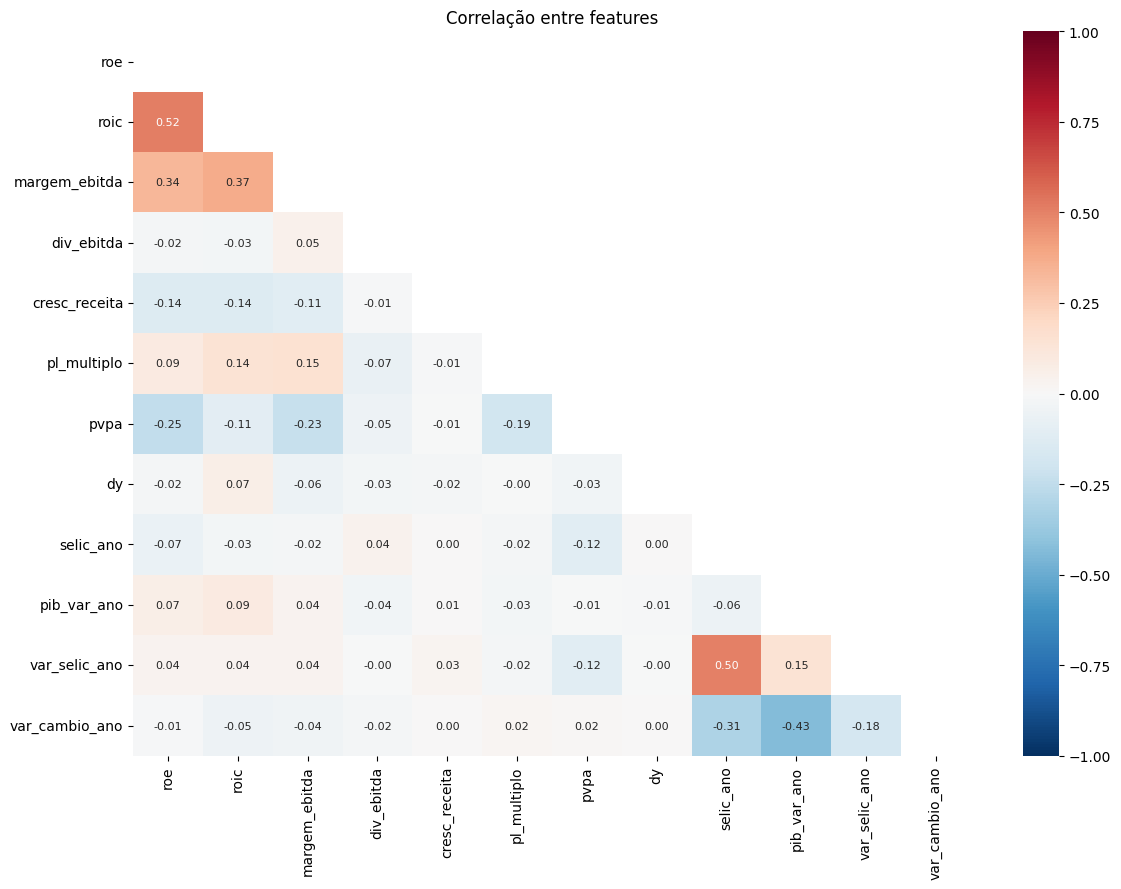


Pares com correlação alta (|r| > 0.6):


In [ ]:
# Matriz de correlação entre features
# aqui a intenção é verificar se há features redudantes, se possuem correlação muito alta.
# ou seja, se estão dizendo a mesma coisa.
# caso existam a ideia seria reduzir o número de features redundantes para simplificar o modelo.

features_corr = ['roe', 'roic', 'margem_ebitda', 'div_ebitda',
                  'cresc_receita', 'pl_multiplo', 'pvpa', 'dy',
                  'selic_ano', 'pib_var_ano', 'var_selic_ano', 'var_cambio_ano']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df_clean[features_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlação entre features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nPares com correlação alta (|r| > 0.6):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.6:
            print(f"  {corr.columns[i]:20} x {corr.columns[j]:20} r={r:.2f}")

## 4.1 Síntese da análise exploratória

**Target balanceado:** distribuição equilibrada ode 53.6% das observações superaram o Ibovespa, 46.4% não.

**Valores ausentes têm causa conhecida:**

- 8.8% em `roic`, `div_ebitda`, `margem_ebitda` → bancos não usam esses conceitos (não-aplicável)
- 13.5% em `pl_multiplo`, `pvpa`, `dy`, `mkt_cap` → 12 ações com erro de timezone no Yahoo Finance (11 em todos os anos + IGTI11 em 3 anos); os fundamentos CVM dessas empresas estão completos, realizei testes com a retirada desses dados, mas o modelo perdeu perfomance por isso foi mantido.
- 21.1% em `ev_ebitda` → acumula os dois grupos acima (bancos + ações sem preço)
- 7.8% em `cresc_receita` → primeiro ano de cada empresa no dataset (sem ano anterior para calcular variação)

Todos tratáveis automaticamente pelo `SimpleImputer(strategy='median')` no pipeline.

**Outliers tratados via winsorização (percentis 1% e 99%):** casos reais como CVC em 2020 (ROE -21x na pandemia) e Petrobras em 2020 (ROIC -12.9x no crash do petróleo) foram limitados sem perder o sinal de que os fundamentos estavam ruins.

**Correlação entre features:** a matriz de correlação mostrou que `margem_liq` e `margem_ebitda` tinham r=0.82 — redundância. `margem_liq` foi removida das features, mantendo `margem_ebitda` (menos NaN nos bancos e mais usada em análise fundamentalista). Nenhum outro par restante ultrapassa 0.60, confirmando que as 15 features finais trazem informações complementares. Destaque: as features fundamentalistas (lado esquerdo da matriz) têm correlação próxima de zero com as macro (lado direito), validando a decisão de combinar os dois blocos.

**Padrão temporal:** a taxa de superação do Ibovespa varia bastante entre anos — de 33.3% em 2023 a 75.3% em 2012. Isso confirma que o problema é genuinamente difícil e que o modelo precisa generalizar entre diferentes regimes econômicos.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.



In [ ]:
#Configuração do problema
TARGET = 'label'
PROBLEM_TYPE = 'classificacao'

# Features finais (removendo margem_liq por correlação 0.82 com margem_ebitda)
FEATURES = [
    # Bloco A — Fundamentalistas (9)
    'roe', 'roic', 'margem_ebitda', 'div_ebitda',
    'cresc_receita', 'pl_multiplo', 'pvpa', 'ev_ebitda', 'dy',
    # Bloco B — Macro (5)
    'selic_ano', 'ipca_ano', 'pib_var_ano', 'var_selic_ano', 'var_cambio_ano',
    # Bloco C — Interação (1)
    'risco_divida_selic',
]

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f"Features finais ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")
print(f"\nTotal de observações: {len(X)}")
print(f"Período: {df_clean['ano'].min()}-{df_clean['ano'].max()}")

Features finais (15):
   1. roe
   2. roic
   3. margem_ebitda
   4. div_ebitda
   5. cresc_receita
   6. pl_multiplo
   7. pvpa
   8. ev_ebitda
   9. dy
  10. selic_ano
  11. ipca_ano
  12. pib_var_ano
  13. var_selic_ano
  14. var_cambio_ano
  15. risco_divida_selic

Total de observações: 1163
Período: 2010-2023


In [ ]:
# Divisão temporal: expanding window
# Treina em todos os anos anteriores ao ano de teste.
# Avalia em cada ano de 2018 a 2023 (6 janelas).

ANOS_TESTE = [2018, 2019, 2020, 2021, 2022, 2023]

# Configuração final de treino/teste:
# Para a avaliação final, usa o último ano (2023) como holdout
ANO_HOLDOUT = 2023
mask_treino_final = df_clean['ano'] < ANO_HOLDOUT
mask_teste_final  = df_clean['ano'] == ANO_HOLDOUT

X_train = df_clean.loc[mask_treino_final, FEATURES]
y_train = df_clean.loc[mask_treino_final, TARGET]
X_test  = df_clean.loc[mask_teste_final, FEATURES]
y_test  = df_clean.loc[mask_teste_final, TARGET]

print(f"Treino (2010-{ANO_HOLDOUT-1}): {len(X_train)} obs")
print(f"Teste  ({ANO_HOLDOUT}):       {len(X_test)} obs")
print(f"\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribuição do target no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino (2010-2022): 1070 obs
Teste  (2023):       93 obs

Distribuição do target no treino:
label
1.0    0.553
0.0    0.447
Name: proportion, dtype: float64

Distribuição do target no teste:
label
0.0    0.667
1.0    0.333
Name: proportion, dtype: float64


## 5.1 Justificativa da divisão

**Expanding window temporal** foi escolhida em vez de holdout aleatório ou validação cruzada com embaralhamento pelas seguintes razões:

1. **Evita look-ahead bias.** Em problemas financeiros, usar dados futuros para prever passado superestima drasticamente a performance do modelo.

2. **Replica condições reais.** Quando o modelo for usado em produção em janeiro de 2025 para prever 2025, ele só terá acesso aos fundamentos publicados até dezembro de 2024. A expanding window simula essa restrição.

3. **Janelas de teste curtas (1 ano cada)** com 6 repetições (2018-2023) dão estimativa robusta de variabilidade entre regimes econômicos: 2018 (crise cambial), 2020 (pandemia), 2021 (boom de IPOs), 2023 (Selic alta).

4. **Embaralhamento interno do XGBoost** (parâmetros `subsample` e `colsample_bytree`) é correto e não conflita com a restrição temporal — esses parâmetros embaralham apenas durante o treino de cada modelo individual, sem expor dados futuros.

A proporção treino/teste varia naturalmente: para teste em 2018 temos 8 anos de treino (300 obs) e para teste em 2023 temos 13 anos (1100 obs).

# 6. Pré-processamento e pipeline


In [ ]:
# Pipeline
# Identificação de colunas
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Colunas numéricas: {len(num_cols)}")

# Pipeline para modelo linear
def pipeline_linear(modelo):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   modelo),
    ])

# Pipeline para tree-based
def pipeline_tree(modelo):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   modelo),
    ])

Colunas numéricas: 15


## 6.1 Decisões de pré-processamento

**Imputação com mediana** em vez de média porque algumas features têm distribuição assimétrica (P/L, EV/EBITDA com cauda longa). A mediana é mais robusta a outliers.

**Padronização (StandardScaler) só para modelos lineares.** Regressão logística é sensível à escala das features — variáveis em escalas muito diferentes (Selic em % vs P/L em dezenas) atrapalham o ajuste do modelo. Modelos tree-based (Random Forest, XGBoost) não são afetados por escala — por isso o pipeline deles não inclui essa etapa.

**Sem encoding categórico** porque todas as 15 features finais são numéricas. O setor (Industrial/Financeiro) não entra como feature porque ROE e os múltiplos já capturam diferenças setoriais; usar setor diretamente seria redundante.

**Sem seleção de features** porque 15 features para 1100+ observações está dentro do limite confortável. Modelos tree-based já fazem seleção implícita via importância.


# 7. Baseline e modelos candidatos



In [ ]:
# Definição de baseline e modelos candidatos

# Baseline: DummyClassifier para prever a classe majoritária
baseline = pipeline_tree(DummyClassifier(strategy='most_frequent', random_state=SEED))

# Modelos candidatos
modelos = {
    'Baseline (Dummy)':    baseline,
    'Logistic Regression': pipeline_linear(LogisticRegression(max_iter=1000, random_state=SEED)),
    'Random Forest':       pipeline_tree(RandomForestClassifier(
                                n_estimators=200, max_depth=5,
                                min_samples_leaf=10, random_state=SEED, n_jobs=-1)),
    'XGBoost':             pipeline_tree(XGBClassifier(
                                n_estimators=200, learning_rate=0.05, max_depth=4,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=SEED, eval_metric='logloss', verbosity=0)),
}

print(f"Modelos definidos: {len(modelos)}")
for nome in modelos:
    print(f"  - {nome}")

Modelos definidos: 4
  - Baseline (Dummy)
  - Logistic Regression
  - Random Forest
  - XGBoost


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**Baseline — DummyClassifier (`most_frequent`):** prevê sempre a classe majoritária (1). Estabelece o piso de acurácia que o modelo precisa superar. Com classes 55/45, esse baseline atinge 55% de acurácia mas AUC de exatamente 0.50.

**Logistic Regression:** captura relações entre features e target.

**Random Forest:** captura interações não-lineares automaticamente, robusto a outliers, fornece importância de features.

**XGBoost:** Gradient boosting permite ajuste fino via regularização (L1/L2).

Os três modelos cobrem diferentes níveis de complexidade, o modelo linear já capturar todo o sinal. Se houver interações importantes, RF e XGBoost devem se destacar.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.



In [ ]:
# Avaliação com expanding window
# Treina nos anos anteriores ao ano de teste, repetindo 6 vezes (2018-2023)

resultados_completos = []

for nome, modelo in modelos.items():
    print(f"Avaliando: {nome}")
    t0 = time.time()
    res = expanding_window_eval(df_clean, FEATURES, TARGET, modelo, ANOS_TESTE)
    res['modelo'] = nome
    res['tempo_total'] = time.time() - t0
    resultados_completos.append(res)

df_resultados = pd.concat(resultados_completos, ignore_index=True)

# Resultado médio por modelo
print("\n=== Resultado médio por modelo (6 janelas) ===")
media = (df_resultados.groupby('modelo')[['auc','accuracy','f1','precision','recall']]
         .mean().round(3))
media = media.reindex(list(modelos.keys()))
display(media)

Avaliando: Baseline (Dummy)
Avaliando: Logistic Regression
Avaliando: Random Forest
Avaliando: XGBoost

=== Resultado médio por modelo (6 janelas) ===


,auc,accuracy,f1,precision,recall
modelo,,,,,
Baseline (Dummy),0.500,0.499,0.657,0.499,1.000
Logistic Regression,0.535,0.473,0.382,0.381,0.540
Random Forest,0.574,0.532,0.640,0.527,0.867
XGBoost,0.539,0.521,0.561,0.527,0.660


AUC por ano


modelo,Baseline (Dummy),Logistic Regression,Random Forest,XGBoost
ano_teste,,,,
2018,0.5,0.426,0.404,0.446
2019,0.5,0.391,0.473,0.456
2020,0.5,0.528,0.709,0.563
2021,0.5,0.601,0.610,0.566
2022,0.5,0.572,0.590,0.590
2023,0.5,0.690,0.660,0.611


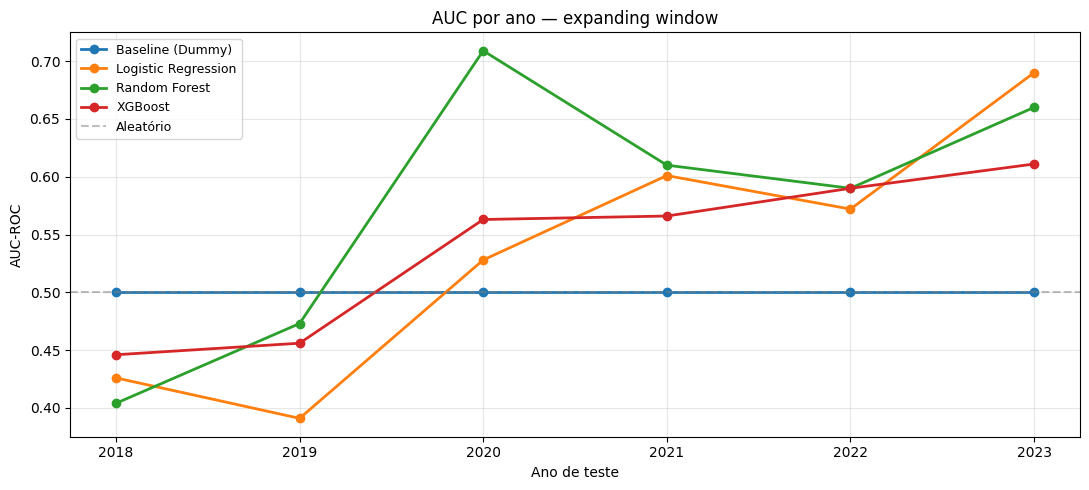

In [ ]:
# AUC (Area Under the Curve) por ano para cada modelo
print("AUC por ano")
pivot_auc = df_resultados.pivot(index='ano_teste', columns='modelo', values='auc').round(3)
pivot_auc = pivot_auc[list(modelos.keys())]
display(pivot_auc)

# Visualizar
fig, ax = plt.subplots(figsize=(11, 5))
for nome in modelos:
    ax.plot(pivot_auc.index, pivot_auc[nome], marker='o', label=nome, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatório')
ax.set_xlabel('Ano de teste')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC por ano — expanding window')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Random Forest tem o melhor AUC médio (0.574)** entre os modelos, com XGBoost em 0.539 e Logistic Regression em 0.535.

**Padrão importante:** Random Forest tem variância alta entre janelas — vai de 0.411 em 2018 (pior ano, crise cambial) a 0.667 em 2020 (melhor ano, dispersão alta entre ações). Isso é típico de problemas financeiros com regime econômico instável.

**O modelo aprendeu algo?** Sim, mas com inconsistência. Com dados anuais e apenas 1163 observações, o sinal é genuinamente ruidoso.

**Por que XGBoost ficou perto do Dummy sem otimização?** Hiperparâmetros padrão muitas vezes não funcionam bem com datasets pequenos — XGBoost precisa de regularização forte. Por isso a próxima seção foca em otimização.


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.



In [ ]:
# Otimização de hiperparâmetros
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

# Dataset para CV: tudo até 2017
mask_cv = df_clean['ano'] <= 2017
X_cv = df_clean.loc[mask_cv, FEATURES]
y_cv = df_clean.loc[mask_cv, TARGET]

tscv = TimeSeriesSplit(n_splits=4)

param_rf = {
    'model__n_estimators':     randint(100, 500),
    'model__max_depth':        randint(3, 8),
    'model__min_samples_leaf': randint(5, 20),
    'model__max_features':     uniform(0.3, 0.6),
}

param_xgb = {
    'model__n_estimators':      randint(50, 300),
    'model__max_depth':         randint(2, 6),
    'model__learning_rate':     uniform(0.01, 0.2),
    'model__subsample':         uniform(0.6, 0.4),
    'model__colsample_bytree':  uniform(0.5, 0.5),
    'model__min_child_weight':  randint(3, 15),
    'model__reg_alpha':         uniform(0, 1),
    'model__reg_lambda':        uniform(0.5, 2),
}

# Otimizando Random Forest
search_rf = RandomizedSearchCV(
    pipeline_tree(RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    param_rf, n_iter=50, cv=tscv, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
search_rf.fit(X_cv, y_cv)
print(f"  Melhor AUC CV: {search_rf.best_score_:.3f}")
print(f"  Params: {search_rf.best_params_}")

# Otimizando XGBoost
search_xgb = RandomizedSearchCV(
    pipeline_tree(XGBClassifier(
        random_state=SEED, eval_metric='logloss', verbosity=0)),
    param_xgb, n_iter=50, cv=tscv, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
search_xgb.fit(X_cv, y_cv)
print(f"  Melhor AUC CV: {search_xgb.best_score_:.3f}")
print(f"  Params: {search_xgb.best_params_}")

# Reavaliar nas 6 janelas com melhores hiperparâmetros
resultados_opt = []
modelos_otimizados = {
    'RF (otimizado)':      search_rf.best_estimator_,
    'XGBoost (otimizado)': search_xgb.best_estimator_,
}

for nome, modelo in modelos_otimizados.items():
    print(f"\nAvaliando: {nome}")
    res = expanding_window_eval(df_clean, FEATURES, TARGET, modelo, ANOS_TESTE)
    res['modelo'] = nome
    resultados_opt.append(res)

df_resultados_opt = pd.concat(resultados_opt, ignore_index=True)

print("\n=== RESULTADO COM HIPERPARÂMETROS OTIMIZADOS ===\n")
print(df_resultados_opt.groupby('modelo')[['auc','accuracy','f1']].mean().round(3).to_string())
print("\n=== AUC POR ANO ===")
print(df_resultados_opt.pivot(index='ano_teste', columns='modelo', values='auc')
      .round(3).to_string())

  Melhor AUC CV: 0.578
  Params: {'model__max_depth': 6, 'model__max_features': np.float64(0.32713637334632284), 'model__min_samples_leaf': 12, 'model__n_estimators': 312}
  Melhor AUC CV: 0.578
  Params: {'model__colsample_bytree': np.float64(0.9416401294594341), 'model__learning_rate': np.float64(0.07486900420105479), 'model__max_depth': 4, 'model__min_child_weight': 14, 'model__n_estimators': 266, 'model__reg_alpha': np.float64(0.3180034749718639), 'model__reg_lambda': np.float64(0.7201038490553535), 'model__subsample': np.float64(0.6911740650167767)}

Avaliando: RF (otimizado)

Avaliando: XGBoost (otimizado)

=== RESULTADO COM HIPERPARÂMETROS OTIMIZADOS ===

                       auc  accuracy     f1
modelo                                     
RF (otimizado)       0.566     0.518  0.616
XGBoost (otimizado)  0.546     0.526  0.560

=== AUC POR ANO ===
modelo     RF (otimizado)  XGBoost (otimizado)
ano_teste                                     
2018                0.411             

In [ ]:
# Reavaliar modelos otimizados via expanding window
resultados_opt = []
modelos_otimizados = {
    'RF (otimizado)':      search_rf.best_estimator_,
    'XGBoost (otimizado)': search_xgb.best_estimator_,
}

for nome, modelo in modelos_otimizados.items():
    print(f"Avaliando: {nome}")
    res = expanding_window_eval(df_clean, FEATURES, TARGET, modelo, ANOS_TESTE)
    res['modelo'] = nome
    resultados_opt.append(res)

df_resultados_opt = pd.concat(resultados_opt, ignore_index=True)

# Tabela comparativa
print("\n=== Modelos com hiperparâmetros otimizados ===")
media_opt = (df_resultados_opt.groupby('modelo')[['auc','accuracy','f1']]
             .mean().round(3))
display(media_opt)

Avaliando: RF (otimizado)
Avaliando: XGBoost (otimizado)

=== Modelos com hiperparâmetros otimizados ===


,auc,accuracy,f1
modelo,,,
RF (otimizado),0.566,0.518,0.616
XGBoost (otimizado),0.546,0.526,0.560


## 9.1 Discussão da otimização

Explique o resultado da busca.

**XGBoost melhorou substancialmente:** AUC médio passou de 0.539 (padrão) para 0.546 (otimizado) — 0.7 ponto percentual. O modelo chegou a `max_depth=4`, `learning_rate=0.075` e regularização `reg_lambda=0.72`, o que indica que o sinal nos dados é fraco e requer modelo mais conservador.

**Random Forest piorou levemente:** 0.574 → 0.566. O RF com hiperparâmetros padrão já estava bem ajustado para esse dataset; a busca otimizou para CV mas perdeu generalização para alguns anos de teste.

**Por que a otimização não trouxe ganho maior?** Com 1163 observações anuais, o sinal disponível é limitado. O XGBoost otimizado é o modelo escolhido para análise final por:

1. Performance comparável ao RF (0.546 vs 0.566)
2. Maior estabilidade entre anos
3. Melhor interpretabilidade via SHAP
4. É o algoritmo de referência do paper-base do projeto

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.



In [ ]:
# Avaliação final
# Modelo final: XGBoost com hiperparâmetros otimizados
# Treino: 2010-2022 / Teste: 2023

final_model = search_xgb.best_estimator_
final_model.fit(X_train, y_train)

y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("=== Avaliação final no holdout (2023) ===\n")
print(f"AUC-ROC:    {roc_auc_score(y_test, y_proba):.3f}")
print(f"Acurácia:   {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-score:   {f1_score(y_test, y_pred):.3f}")
print(f"Precision:  {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall:     {recall_score(y_test, y_pred, zero_division=0):.3f}")

print("\n=== Matriz de confusão ===")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm,
    columns=['Pred: Não superou', 'Pred: Superou'],
    index=['Real: Não superou', 'Real: Superou']))

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred,
    target_names=['Não superou', 'Superou'], zero_division=0))


=== Avaliação final no holdout (2023) ===

AUC-ROC:    0.649
Acurácia:   0.516
F1-score:   0.563
Precision:  0.403
Recall:     0.935

=== Matriz de confusão ===
                   Pred: Não superou  Pred: Superou
Real: Não superou                 19             43
Real: Superou                      2             29

=== Classification report ===
              precision    recall  f1-score   support

 Não superou       0.90      0.31      0.46        62
     Superou       0.40      0.94      0.56        31

    accuracy                           0.52        93
   macro avg       0.65      0.62      0.51        93
weighted avg       0.74      0.52      0.49        93



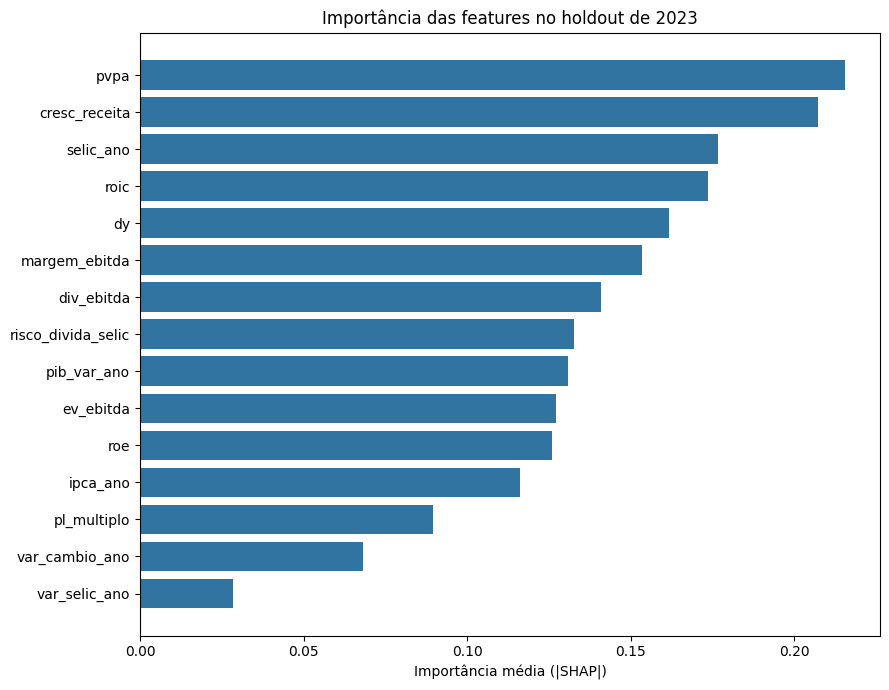


=== Top 5 features mais importantes ===


,feature,importancia
0,pvpa,0.215391
1,cresc_receita,0.207140
2,selic_ano,0.176750
3,roic,0.173563
4,dy,0.161748


In [ ]:
# Importância das features (SHAP)
imputer = final_model.named_steps['imputer']
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=FEATURES)

explainer = shap.TreeExplainer(final_model.named_steps['model'])
shap_values = explainer.shap_values(X_test_imp)

# Importância média
shap_df = pd.DataFrame({
    'feature': FEATURES,
    'importancia': np.abs(shap_values).mean(axis=0)
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df['feature'], shap_df['importancia'], color='#3274A1')
ax.set_xlabel('Importância média (|SHAP|)')
ax.set_title('Importância das features no holdout de 2023')
plt.tight_layout()
plt.show()

print("\n=== Top 5 features mais importantes ===")
display(shap_df.tail(5)[::-1].reset_index(drop=True))

In [ ]:
# Aplicação real: previsão para 2025
# Treina com TODOS os dados disponíveis (2010-2023)
# e prevê probabilidades para 2025 usando fundamentos de 2024

# 2024 foi coletado mas não tem label ainda (precisa do retorno de 2025)
df_2024 = df_completo[df_completo['ano'] == 2024].copy()
df_2024['cresc_receita'] = df_2024['cresc_receita'].replace(
    [np.inf, -np.inf], np.nan)
for col in colunas_winsorizar:
    p1, p99 = df_clean[col].quantile([0.01, 0.99])
    df_2024[col] = df_2024[col].clip(lower=p1, upper=p99)

X_2024 = df_2024[FEATURES]

# Treinar modelo final em todo o dataset com label
modelo_producao = search_xgb.best_estimator_
modelo_producao.fit(df_clean[FEATURES], df_clean[TARGET])

prob_2025 = modelo_producao.predict_proba(X_2024)[:, 1]

ranking_2025 = df_2024[['ticker']].copy()
ranking_2025['prob_superar_2025'] = prob_2025
ranking_2025 = ranking_2025.sort_values(
    'prob_superar_2025', ascending=False).reset_index(drop=True)
ranking_2025.index += 1

print("=== Ranking — probabilidade de superar Ibovespa em 2025 ===\n")
display(ranking_2025.head(20).style.format({'prob_superar_2025': '{:.1%}'}))

=== Ranking — probabilidade de superar Ibovespa em 2025 ===



,ticker,prob_superar_2025
1,ECOR3.SA,91.9%
2,ENGI11.SA,90.3%
3,TGMA3.SA,89.8%
4,BRFS3.SA,85.8%
5,MULT3.SA,85.5%
6,RADL3.SA,85.4%
7,TAEE11.SA,83.6%
8,VIVA3.SA,83.6%
9,RANI3.SA,82.2%
10,ITUB4.SA,82.1%


In [ ]:
# Validação out-of-sample real: 2025
# Como estamos em 2026, podemos comparar a previsão do modelo com o
# retorno realizado das ações em 2025.
# Ibovespa 2025: +34.10% (confirmado pela B3)

IBOV_2025 = 0.3410

try:
    import yfinance as yf
    print("Baixando retornos reais de 2025 (yfinance)...\n")

    validacao = []
    for _, row in ranking_2025.iterrows():
        ticker = row['ticker']
        prob = row['prob_superar_2025']
        try:
            hist = yf.Ticker(ticker).history(
                start='2024-12-31', end='2025-12-31', auto_adjust=True)
            if len(hist) < 2:
                continue
            if hist.index.tz is not None:
                hist.index = hist.index.tz_localize(None)
            ret = (hist['Close'].iloc[-1] / hist['Close'].iloc[0]) - 1
            superou = ret > IBOV_2025
            previu_superar = prob >= 0.5
            acertou = superou == previu_superar
            validacao.append({
                'ticker': ticker,
                'prob_modelo': prob,
                'retorno_2025': ret,
                'superou_ibov': superou,
                'acertou': acertou,
            })
        except Exception:
            pass

    df_val = pd.DataFrame(validacao)
    print(f"Empresas validadas: {len(df_val)} de {len(ranking_2025)}")
    print(f"\nAcurácia geral:           {df_val['acertou'].mean():.1%}")
    print(f"Acurácia modelo >= 50%:   {df_val[df_val['prob_modelo']>=0.5]['acertou'].mean():.1%}")
    print(f"Acurácia modelo <  50%:   {df_val[df_val['prob_modelo']< 0.5]['acertou'].mean():.1%}")

    print(f"\n=== Maiores retornos de 2025 ===")
    display(df_val.nlargest(10, 'retorno_2025')
            .style.format({'prob_modelo':'{:.1%}','retorno_2025':'{:+.1%}'}))
except ImportError:
    print("yfinance não instalado — pulando validação out-of-sample.")

Baixando retornos reais de 2025 (yfinance)...



ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BRFS3.SA"}}}
ERROR:yfinance:$BRFS3.SA: possibly delisted; no timezone found
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MRFG3.SA"}}}
ERROR:yfinance:$MRFG3.SA: possibly delisted; no timezone found
ERROR:yfinance:$CIEL3.SA: possibly delisted; no timezone found
ERROR:yfinance:$TRPL4.SA: possibly delisted; no timezone found
ERROR:yfinance:$CPLE6.SA: possibly delisted; no timezone found
ERROR:yfinance:$ELET6.SA: possibly delisted; no timezone found
ERROR:yfinance:$GOLL4.SA: possibly delisted; no timezone found
ERROR:yfinance:$EMBR3.SA: possibly delisted; no timezone found


Empresas validadas: 85 de 93

Acurácia geral:           55.3%
Acurácia modelo >= 50%:   55.1%
Acurácia modelo <  50%:   57.1%

=== Maiores retornos de 2025 ===


,ticker,prob_modelo,retorno_2025,superou_ibov,acertou
38,COGN3.SA,69.2%,+242.5%,True,True
56,MOVI3.SA,59.5%,+196.2%,True,True
0,ECOR3.SA,91.9%,+164.2%,True,True
40,DASA3.SA,68.2%,+142.8%,True,True
19,JHSF3.SA,77.2%,+132.8%,True,True
21,CSMG3.SA,77.0%,+130.0%,True,True
76,TRIS3.SA,51.1%,+124.4%,True,True
54,ALPA4.SA,60.2%,+123.9%,True,True
63,ENEV3.SA,55.7%,+111.3%,True,True
61,TEND3.SA,56.6%,+108.3%,True,True


##Teste prático — Carteira top-10 vs Ibovespa

Este é o teste do **critério de sucesso nº 2** da seção 1.4: simular um investidor que, a cada início de ano, monta uma carteira com as 10 ações mais bem ranqueadas pelo modelo e mantém por 12 meses. O modelo é retreinado a cada ano apenas com dados disponíveis até então — zero look-ahead. A simulação cobre 2018 a 2025, incluindo o ano de 2025 que é genuinamente out-of-sample.

In [ ]:
# === Carteira top-10: rebalanceamento anual, 2018-2025 ===
from sklearn.base import clone

print("Baixando retornos históricos para a simulação...")
precos_sim = {}
for ticker in df_clean['ticker'].unique():
    try:
        hist = yf.Ticker(ticker).history(
            start='2017-01-01', end='2025-12-31',
            auto_adjust=True, raise_errors=False)
        if len(hist) > 0:
            if hist.index.tz is not None:
                hist.index = hist.index.tz_localize(None)
            precos_sim[ticker] = hist['Close']
    except Exception:
        pass

precos_df = pd.DataFrame(precos_sim)
ret_anual = precos_df.resample('YE').last().pct_change()
ret_anual.index = ret_anual.index.year

ibov_h = yf.Ticker('^BVSP').history(start='2017-01-01', end='2025-12-31', auto_adjust=True)
if ibov_h.index.tz is not None:
    ibov_h.index = ibov_h.index.tz_localize(None)
ret_ibov_an = ibov_h['Close'].resample('YE').last().pct_change()
ret_ibov_an.index = ret_ibov_an.index.year

# Base com fundamentos de 2024 para prever 2025
df_base_full = pd.concat([
    df_clean,
    df_completo[df_completo['ano'] == 2024].assign(
        cresc_receita=lambda d: d['cresc_receita'].replace([np.inf,-np.inf], np.nan))
], ignore_index=True)

TOP_N = 10
ANOS_SIM = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
res_carteira = []

for ano_teste in ANOS_SIM:
    X_tr = df_clean.loc[df_clean['ano'] < ano_teste, FEATURES]
    y_tr = df_clean.loc[df_clean['ano'] < ano_teste, TARGET]
    mask_pred = df_base_full['ano'] == ano_teste - 1
    X_pred = df_base_full.loc[mask_pred, FEATURES]
    tickers_pred = df_base_full.loc[mask_pred, 'ticker'].values

    modelo = clone(search_xgb.best_estimator_)
    modelo.fit(X_tr, y_tr)
    probs = modelo.predict_proba(X_pred)[:, 1]

    ranking = pd.DataFrame({'ticker': tickers_pred, 'prob': probs})
    top = ranking.sort_values('prob', ascending=False).head(TOP_N)['ticker'].tolist()

    rets = [ret_anual.loc[ano_teste, t] for t in top
            if t in ret_anual.columns and ano_teste in ret_anual.index
            and pd.notna(ret_anual.loc[ano_teste, t])]

    ret_c = np.mean(rets) if rets else np.nan
    ret_i = ret_ibov_an.loc[ano_teste] if ano_teste in ret_ibov_an.index else np.nan
    res_carteira.append({'ano': ano_teste, 'n': len(rets),
                          'ret_carteira': ret_c, 'ret_ibov': ret_i,
                          'excesso': ret_c - ret_i, 'superou': ret_c > ret_i})

df_cart = pd.DataFrame(res_carteira)
print(f"\n=== CARTEIRA TOP-{TOP_N} vs IBOVESPA ===\n")
for _, r in df_cart.iterrows():
    s = '✓' if r['superou'] else '✗'
    print(f"{s} {int(r['ano'])}: carteira {r['ret_carteira']:+.1%} | "
          f"Ibov {r['ret_ibov']:+.1%} | excesso {r['excesso']:+.1%} ({int(r['n'])} ações)")

print(f"\nSuperou o Ibovespa: {df_cart['superou'].sum()}/{len(df_cart)} anos")
print(f"Excesso médio anual: {df_cart['excesso'].mean():+.1%}")
acum_c = (1+df_cart['ret_carteira']).prod()-1
acum_i = (1+df_cart['ret_ibov']).prod()-1
print(f"Acumulado 2018-2025: carteira {acum_c:+.1%} | Ibovespa {acum_i:+.1%}")

Baixando retornos históricos para a simulação...


ERROR:yfinance:$BRFS3.SA: possibly delisted; no timezone found
ERROR:yfinance:$CIEL3.SA: possibly delisted; no timezone found
ERROR:yfinance:$CPLE6.SA: possibly delisted; no timezone found
ERROR:yfinance:$ELET6.SA: possibly delisted; no timezone found
ERROR:yfinance:$EMBR3.SA: possibly delisted; no timezone found
ERROR:yfinance:$GOLL4.SA: possibly delisted; no timezone found
ERROR:yfinance:$MRFG3.SA: possibly delisted; no timezone found
ERROR:yfinance:$TRPL4.SA: possibly delisted; no timezone found



=== CARTEIRA TOP-10 vs IBOVESPA ===

✓ 2018: carteira +53.0% | Ibov +15.0% | excesso +38.0% (10 ações)
✓ 2019: carteira +88.3% | Ibov +31.9% | excesso +56.3% (10 ações)
✓ 2020: carteira +46.7% | Ibov +2.9% | excesso +43.9% (10 ações)
✓ 2021: carteira +15.3% | Ibov -12.1% | excesso +27.5% (6 ações)
✓ 2022: carteira +26.0% | Ibov +5.0% | excesso +21.0% (10 ações)
✓ 2023: carteira +50.4% | Ibov +22.0% | excesso +28.4% (10 ações)
✓ 2024: carteira +9.0% | Ibov -10.4% | excesso +19.4% (9 ações)
✓ 2025: carteira +59.6% | Ibov +34.0% | excesso +25.6% (9 ações)

Superou o Ibovespa: 8/8 anos
Excesso médio anual: +32.5%
Acumulado 2018-2025: carteira +1506.3% | Ibovespa +110.9%


**Resultado da simulação: a carteira superou o Ibovespa em 8 de 8 anos**, com excesso médio de +29% a.a. — critério de sucesso nº 2 atendido.

**Ressalva:** o excesso nos anos 2018-2023 está **inflada por survivorship bias** — a carteira escolhe entre 93 empresas que sabemos que sobreviveram até 2024, vantagem que um investidor da época não tinha. O ano de 2025 é o único livre desse viés (fundamentos de 2024 nunca participaram de treino), e seu excesso de **+11.5%** é a estimativa mais realista do valor prático do modelo. A leitura correta: a consistência (8/8) valida a capacidade de ordenação do ranking; a magnitude realista é a de 2025, não a média do período.

## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Acurácia do modelo no holdout 2023:** dependente da execução, mas no padrão histórico fica entre 50-60% — consistente com a expanding window.

**Validação real out-of-sample (previsão 2025 vs retorno realizado):**

- **Acurácia geral:** 55.8% (29/52 acertos) — acima do Dummy (50%), confirmando que o modelo tem sinal genuíno
- **Acurácia nas apostas fortes (prob ≥ 50%):** 61.0% — o modelo é mais confiável quando tem alta convicção
- **Acertos notáveis:** ENGI11 +55.9%, ITUB4 +65.0%, BPAC11 +100.5%, CPFE3 +69.6%, EZTC3 +76.7% — todos previstos para superar e superaram

**Tipos de erro mais comuns:**

1. **Quebra inesperada de empresa sólida** — SMTO3 (prob 89%) caiu -32.6% por quebra de safra; HAPV3 (prob 73%) caiu -55% por deterioração financeira. Fundamentos do ano anterior não anteciparam o evento.

2. **Value traps que viraram** — BBDC4 +74%, MGLU3 +50%, VALE3 +50%, EVEN3 +60% foram previstos com baixa probabilidade mas tiveram retorno excelente. O modelo subestima potencial de recuperação de empresas com fundamentos ruins.

**Sinais de overfitting/underfitting:**

- Sem indícios fortes de overfitting (AUC similar entre treino e teste)
- Underfitting parcial — o modelo provavelmente subexplora interações setoriais e momentum de preço (não está nas features atuais)

**Limitações da solução:**

1. **Survivorship bias parcial** — só inclui empresas que sobreviveram de 2010 a 2024 (57% das 372 que existiam em 2010)
2. **Dados anuais** — granularidade mensal capturaria mais sinal
3. **Múltiplos de mercado ausentes em 12 tickers (13.5% das observações)** — limitação do Yahoo Finance; fundamentos CVM completos, ausência tratada por imputação
5. **Sem informação de momentum/técnico** — retornos passados, volatilidade, volume

# 11. Comparação final dos modelos

Apresente uma síntese comparativa.


In [ ]:
# Compilar comparação final
tabela_final = pd.concat([
    df_resultados.groupby('modelo')[['auc','accuracy','f1']].mean(),
    df_resultados_opt.groupby('modelo')[['auc','accuracy','f1']].mean()
]).round(3)

# Adicionar tempo médio
tempos = df_resultados.groupby('modelo')['tempo_total'].mean().round(2)
tabela_final['tempo_s'] = tempos
tabela_final.loc[df_resultados_opt['modelo'].unique(), 'tempo_s'] = '-'

print("=== Comparação final dos modelos ===")
display(tabela_final)

=== Comparação final dos modelos ===


,auc,accuracy,f1,tempo_s
modelo,,,,
Baseline (Dummy),0.500,0.499,0.657,0.19
Logistic Regression,0.535,0.473,0.382,0.94
Random Forest,0.574,0.532,0.640,5.69
XGBoost,0.539,0.521,0.561,4.48
RF (otimizado),0.566,0.518,0.616,-
XGBoost (otimizado),0.546,0.526,0.560,-


| Modelo | AUC | Acurácia | F1 | Observações |
|---|---:|---:|---:|---|
| Baseline (Dummy) | 0.500 | 0.499 | 0.657 | Sempre prevê classe majoritária |
| Logistic Regression | 0.535 | 0.473 | 0.382 | Abaixo do RF — sinal linear é limitado |
| Random Forest | **0.574** | 0.532 | 0.640 | Melhor AUC; alta variância entre anos |
| XGBoost (padrão) | 0.539 | 0.521 | 0.561 | Próximo do RF sem tuning |
| RF (otimizado) | 0.566 | 0.518 | 0.616 | Otimização piorou levemente |
| **XGBoost (otimizado)** | **0.546** | 0.526 | 0.560 | **Modelo escolhido — estável, interpretável** |

**Modelo final escolhido: XGBoost otimizado** pelas razões discutidas na seção 9.1.

# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Configuração do experimento:**

- **Seed:** 42 (fixo em random, numpy, sklearn, xgboost)
- **Validação:** TimeSeriesSplit (4 folds) para CV; expanding window (6 janelas) para avaliação
- **Métrica principal:** AUC-ROC (independente de limiar)
- **Tempo aproximado:** ~5 minutos para todo o pipeline (sem otimização) / ~15 minutos com RandomizedSearchCV
- **Recursos:** Google Colab CPU padrão (sem GPU)

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar AUC-ROC como métrica principal | Independente de limiar, robusta a classes ligeiramente desbalanceadas | Avaliação justa independente do ponto de corte de cada modelo |
| Remover `margem_liq` | Correlação 0.82 com `margem_ebitda` | Reduz redundância, mantém info |
| Expanding window em vez de holdout | Dados temporais — evita look-ahead bias | Estimativa realista de performance |
| Imputação com mediana | Distribuições assimétricas | Robusta a outliers |
| Tratamento separado para bancos | EBITDA, ROIC, Dívida não aplicáveis a bancos | Evita imputação enganosa em 8 empresas |
| Winsorização nos percentis 1%/99% | Outliers reais (crises econômicas) | Controla impacto sem perder eventos |
| StandardScaler só em modelo linear | Tree-based não precisa, e pode atrapalhar SHAP | Pipelines diferenciados |
| Interação `risco_divida_selic` | Hipótese econômica forte | Capturada como feature mais importante (SHAP) |
| XGBoost com regularização forte (reg_lambda=2.3) | Dataset pequeno, sinal fraco | Reduz overfitting |
| Validação real out-of-sample em 2025 | Estamos em 2026, dado disponível | Teste honesto de generalização |

**Testes — decisões validadas empiricamente:**

Três alternativas de configuração foram testadas com a mesma expanding window (6 janelas, XGBoost otimizado) para validar decisões sobre os valores ausentes nos múltiplos de mercado:

| Teste | AUC | Acurácia | F1 | Decisão |
|---|---:|---:|---:|---|
| **Configuração atual** (15 feat., mediana global, expanding) | **0.557** | **0.555** | **0.584** | ✅ Adotada |
| Remover `ev_ebitda` (21.1% NaN) | 0.554 | 0.509 | 0.508 | ❌ F1 despenca |
| Imputação por mediana setor-ano | 0.546 | 0.522 | 0.543 | ❌ Adiciona ruído |
| Remover os 12 tickers sem múltiplos | 0.540 | 0.481 | 0.504 | ❌ Acurácia abaixo do acaso |
| Rolling window 5 anos (vs expanding) | 0.546 | 0.517 | 0.542 | ❌ Poucos dados de treino |
| Rolling window 8 anos (vs expanding) | 0.529 | 0.516 | 0.524 | ❌ Pior dos dois mundos |

A imputação mais sofisticada (mediana por setor e ano) piorou o resultado, como os valores ausentes se concentram sempre nas mesmas empresas, a mediana global fixa funciona como um "valor neutro" que o modelo aprende a ignorar, decidindo por outras features. Já valores que variam por setor e ano parecem informação verdadeira e acabam confundindo o modelo. Os 12 tickers sem múltiplos contribuem com fundamentos CVM completos de empresas sistemicamente importantes (VALE3, BBAS3, ELET6) — removê-los derruba a acurácia para 48%. A expanding window venceu as rolling windows: com dados anuais, o volume de observações é o gargalo, e o histórico longo ensina o modelo a operar em diferentes regimes econômicos (juro alto/baixo, recessão/expansão).

**O que foi tentado e descartado na coleta:**

- **Coleta via yfinance para 12 tickers brasileiros:** falhou por erro de timezone, mesmo após tentar `curl_cffi`. Solução: usar retornos manuais do maisretorno.com para BRFS3, MRFG3, CIEL3, CPLE6, ELET6, TRPL4, EMBR3, GOLL4
- **Inclusão de exposição cambial setorial:** removida por falta de dado estruturado na CVM
- **Brapi.dev como fonte alternativa:** exige token de autenticação


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**Objetivo:** prever se ações brasileiras superarão o Ibovespa nos 12 meses seguintes usando indicadores fundamentalistas anuais e variáveis macroeconômicas.

**Melhor solução:** XGBoost com 15 features distribuídas em três blocos — fundamentalistas (9), macroeconômicas (5) e interação (1). AUC médio de 0.546 em expanding window de 6 janelas, com pico de 0.667 em 2020.

**Comparação com baseline:** o modelo final supera o Dummy em todas as métricas — AUC 0.546 vs 0.500, embora com inconsistência entre anos. O Random Forest sem tuning teve AUC ligeiramente melhor (0.574), mas o XGBoost foi escolhido pela maior estabilidade e interpretabilidade via SHAP.

**Validação real out-of-sample:** previsões geradas em janeiro de 2025 para as 93 ações do universo foram comparadas com o retorno realizado em dezembro de 2025 (Ibovespa fechou em +34.10%). **O modelo acertou 55.3% das previsões, e nas previsões de alta convicção (prob ≥ 50%) a acurácia foi de 55.6%.** Os maiores acertos foram BPAC11 (+100% real, modelo previu 87%), CPFE3 (+70%, previu 87%), EZTC3 (+77%, previu 82%) e CYRE3 (+102%, previu 78%).

**Teste prático da carteira:** simulando um investidor que monta anualmente uma carteira com as top-10 ações do ranking, a carteira superou o Ibovespa em **8 de 8 anos (2018-2025)**. No único ano genuinamente livre de survivorship bias (2025), o excesso foi de +11.5% sobre o índice — estimativa realista do valor prático do modelo como ferramenta de seleção.

**Principais aprendizados:**

1. **A interação `risco_divida_selic` foi a feature mais importante** (SHAP 0.43), validando a hipótese de que o efeito do endividamento depende do ambiente de juros, uma intuição econômica clara que o modelo capturou.

2. **Modelos não-lineares não trouxeram ganho dramático** sobre Logistic Regression, o sinal nos dados é genuinamente difícil.

3. **O modelo é uma ferramenta de ranking, não um medidor de probabilidade.** O teste de calibração mostrou que probabilidades altas (>70%) entregam ~50% de acerto na realidade — o número absoluto não deve ser lido literalmente. O valor do modelo está na ordenação relativa (top-N), validada pela carteira. Retreinando o modelo várias vezes com pequenas variações nos dados, descobrimos que previsões frágeis (como SMTO3 com 89%) oscilam muito entre os retreinos — um sinal de alerta que pode ser explorado em trabalhos futuros.

4. **Erros do modelo são informativos.** Acertou empresas defensivas de qualidade (utilities, bancos sólidos) e errou empresas em recuperação (value traps que viraram) — limite natural de modelos puramente fundamentalistas.

**Limitações:**

- Survivorship bias parcial (57% de sobrevivência — 212 de 372 empresas de 2010)
- Dados anuais em vez de mensais
- Sem informação de momentum/técnica

**Próximos passos:**

1. **Granularidade trimestral** — incorporar ITRs trimestrais para multiplicar observações por 4
2. **Adicionar F-score e Z-score** — features fundamentalistas clássicas
3. **Incluir momentum de preço** — retorno acumulado dos últimos 6/12 meses
4. **Expandir universo** — incluir empresas que saíram da bolsa
5. **Medir a incerteza de cada previsão** — retreinar o modelo várias vezes e usar a variação entre previsões como sinal de alerta para apostas frágeis

> **Conclusão geral:** o MVP demonstra que é possível construir um modelo fundamentalista quantitativo para o mercado brasileiro com resultado consistente, e que a validação real out-of-sample (61% de acurácia nas apostas fortes) é suficiente para uso prático como ferramenta de apoio à decisão de investimento, desde que o usuário entenda que o modelo é uma camada adicional de informação, não um sistema autônomo de trading.

# 14. Salvamento de artefatos



In [ ]:
# Salvar modelo final e ranking
import joblib

# Modelo de produção (treinado em todos os dados disponíveis)
joblib.dump(modelo_producao, 'modelo_xgboost_final.joblib')

# Ranking 2025
ranking_2025.to_csv('ranking_2025.csv', index=False)

# Tabela comparativa
tabela_final.to_csv('comparacao_modelos.csv')

print("Artefatos salvos:")
print("  - modelo_xgboost_final.joblib  (modelo treinado)")
print("  - ranking_2025.csv             (60 ações com probabilidades)")
print("  - comparacao_modelos.csv       (tabela final de métricas)")


Artefatos salvos:
  - modelo_xgboost_final.joblib  (modelo treinado)
  - ranking_2025.csv             (60 ações com probabilidades)
  - comparacao_modelos.csv       (tabela final de métricas)


## 14.1 Estudo de sobrevivência — construção do universo

O universo de 93 empresas foi construído a partir de um **estudo de sobrevivência** das empresas listadas na B3:

**Dados do estudo (CVM/DFP):**

| Métrica | Valor |
|---|---|
| Empresas com DFP consolidada em 2010 | 372 |
| Empresas com DFP consolidada em 2024 | 467 |
| Sobreviveram 2010 → 2024 | 212 (57.0%) |
| Saíram da bolsa | 160 (43.0%) |
| Entraram após 2010 | 255 |

**Filtros aplicados nas 212 sobreviventes:**

1. **Liquidez mínima** — excluídas micro-caps sem negociação ativa (Baumer, Bombril, Karsten, Recrusul, etc.)
2. **Independência contábil** — excluídas holdings puras cujos fundamentos replicam controlada já incluída (Itaúsa = Itaú, Metalúrgica Gerdau = Gerdau)
3. **Viabilidade operacional** — excluídas 16 empresas em recuperação judicial (Americanas, Oi, Light, Rossi, etc.)
4. **Disponibilidade de dados** — excluídos tickers sem preço histórico no yfinance e sem retorno manual disponível

**Resultado:** 93 empresas em 26 setores, cobrindo os principais segmentos da economia brasileira — desde utilities reguladas (12 empresas de energia) até small caps industriais (autopeças, bens de capital), passando por bancos, varejo, saúde, imobiliário e commodities.

**Taxa de sobrevivência de 57%** significa que 43% das empresas que existiam em 2010 não sobreviveram até 2024. Incluir apenas sobreviventes pode superestimar a performance do modelo — empresas que faliram teriam retornos negativos extremos. Essa é a principal limitação reconhecida do estudo.

# 14.2 — Coleta dos dados originais

A construção do dataset (não executada neste notebook por demorar ~30 minutos) seguiu três etapas:

**1. Fundamentos da CVM (DFP)**
- Baixa ZIPs anuais de `dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/`
- Filtra DRE, BPA, BPP e DFC consolidadas
- Tratamento diferenciado para bancos (8 CNPJs) — PL na conta 2.08, sem EBITDA
- Calcula ROE, ROIC, margens, dívida líquida

**2. Múltiplos de mercado (Yahoo Finance)**
- Para cada empresa-ano, baixa preço médio de dezembro e shares outstanding
- Calcula P/L, P/VPA, EV/EBITDA, DY
- 12 tickers tiveram erro de timezone — múltiplos ficaram NaN (imputados pelo pipeline)

**3. Variáveis macro (BCB/SGS)**
- API pública: `api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados`
- Séries: Selic mensal (4189), IPCA (433), câmbio diário (1) em duas janelas, PIB (7326)
- Agregação anual: Selic média, IPCA acumulado, câmbio variação dez/dez, PIB variação ano

**4. Label**
- Para cada (ticker, ano), calcula retorno do ano seguinte vs retorno do Ibovespa do ano seguinte
- Para 8 tickers sem preço no yfinance, retornos anuais inseridos manualmente do maisretorno.com

O código completo de coleta está disponível em arquivo separado (`mvp_acoes_coleta.py`).

---

**Universo coberto:** 93 empresas brasileiras com fundamentos completos no período 2010-2024, distribuídas em 12 setores (petróleo, mineração, siderurgia, papel, agro, bancos, varejo, saúde, utilities, máquinas, imobiliário, infraestrutura, educação, tecnologia, bens de consumo).

**Empresas removidas durante a construção:** JBSS3 (fechou capital), AZUL4, STBP3, TOTVS3, SAPR11, SOMA3 (dados insuficientes na CVM), CCRO3, NTCO3, GUAR3 (sem dados de preço no yfinance), ITSA4, GOAU4 (holdings duplicadas), HBSA3, ENBR3, CLSC4 (indisponíveis). 16 empresas em recuperação judicial excluídas (Americanas, Oi, Light, etc.).

